<a href="https://colab.research.google.com/github/CarlosDouradoPGR/Portifolio/blob/main/modelo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
##Bibliotecas
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn import tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("dados.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   data                    272 non-null    object 
 1   hora                    272 non-null    int64  
 2   n_dia_semana            272 non-null    int64  
 3   qtd_volumes_real        272 non-null    int64  
 4   prev_volumes_hora       272 non-null    int64  
 5   desvio_volumes_hora     272 non-null    int64  
 6   prev_volumes_acumulado  272 non-null    int64  
 7   qtd_volumes_acumulado   272 non-null    int64  
 8   pct_do_real             272 non-null    float64
 9   pct_acumulado_real      272 non-null    float64
 10  pct_esperado_historico  272 non-null    float64
 11  pct_desvio              272 non-null    float64
 12  prev_volumes_totais     272 non-null    int64  
 13  total_captado           272 non-null    int64  
dtypes: float64(4), int64(9), object(1)
memory 

In [6]:
df["data"] = pd.to_datetime(df["data"])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   data                    272 non-null    datetime64[ns]
 1   hora                    272 non-null    int64         
 2   n_dia_semana            272 non-null    int64         
 3   qtd_volumes_real        272 non-null    int64         
 4   prev_volumes_hora       272 non-null    int64         
 5   desvio_volumes_hora     272 non-null    int64         
 6   prev_volumes_acumulado  272 non-null    int64         
 7   qtd_volumes_acumulado   272 non-null    int64         
 8   pct_do_real             272 non-null    float64       
 9   pct_acumulado_real      272 non-null    float64       
 10  pct_esperado_historico  272 non-null    float64       
 11  pct_desvio              272 non-null    float64       
 12  prev_volumes_totais     272 non-null    int64     

In [8]:
df.sort_values('data')

,data,hora,n_dia_semana,qtd_volumes_real,prev_volumes_hora,desvio_volumes_hora,prev_volumes_acumulado,qtd_volumes_acumulado,pct_do_real,pct_acumulado_real,pct_esperado_historico,pct_desvio,prev_volumes_totais,total_captado
0,2025-10-01,15,2,375,470,-95,2973,2298,5.53,33.86,43.8,-9.94,6787,5009
1,2025-10-02,15,3,322,472,-150,2984,2214,4.73,32.50,43.8,-11.30,6812,4655
2,2025-10-03,15,4,314,418,-104,2643,1777,5.20,29.45,43.8,-14.35,6033,3529
3,2025-10-04,15,5,176,99,77,626,1192,12.32,83.41,43.8,39.61,1429,2304
4,2025-10-05,15,6,118,147,-29,928,842,5.57,39.75,43.8,-4.05,2118,1735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,2026-06-27,15,5,157,126,31,795,1136,8.65,62.59,43.8,18.79,1815,2180
268,2026-06-28,15,6,125,70,55,440,690,12.46,68.79,43.8,24.99,1003,1455
269,2026-06-29,15,0,162,242,-80,1530,1302,4.64,37.30,43.8,-6.50,3491,3199
270,2026-06-30,15,1,281,285,-4,1799,1676,6.84,40.82,43.8,-2.98,4106,3753


In [9]:
df.columns

Index(['data', 'hora', 'n_dia_semana', 'qtd_volumes_real', 'prev_volumes_hora',
       'desvio_volumes_hora', 'prev_volumes_acumulado',
       'qtd_volumes_acumulado', 'pct_do_real', 'pct_acumulado_real',
       'pct_esperado_historico', 'pct_desvio', 'prev_volumes_totais',
       'total_captado'],
      dtype='object')

<Axes: >

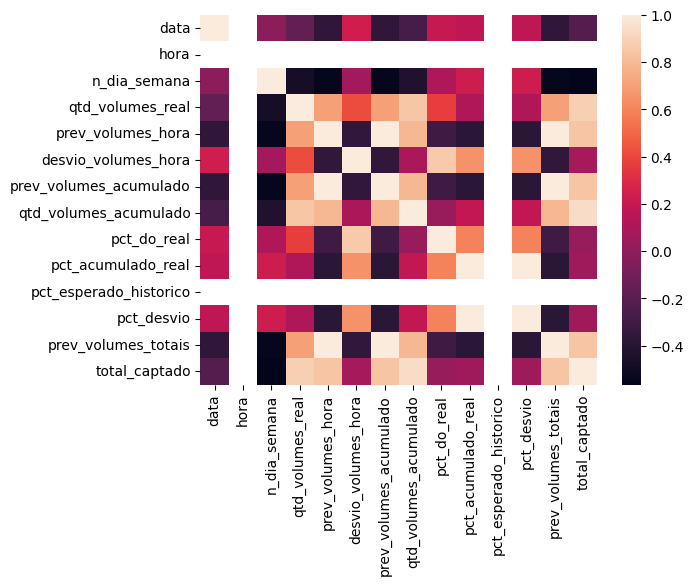

In [10]:
sns.heatmap(df.corr())

### Retirando as colunas hora, pct_esperado_historico que são constantes

In [11]:
df = df[['data', 'n_dia_semana', 'qtd_volumes_real',
       'prev_volumes_hora', 'desvio_volumes_hora', 'prev_volumes_acumulado',
       'qtd_volumes_acumulado', 'pct_do_real', 'pct_acumulado_real', 'pct_desvio', 'prev_volumes_totais',
       'total_captado']]

<Axes: >

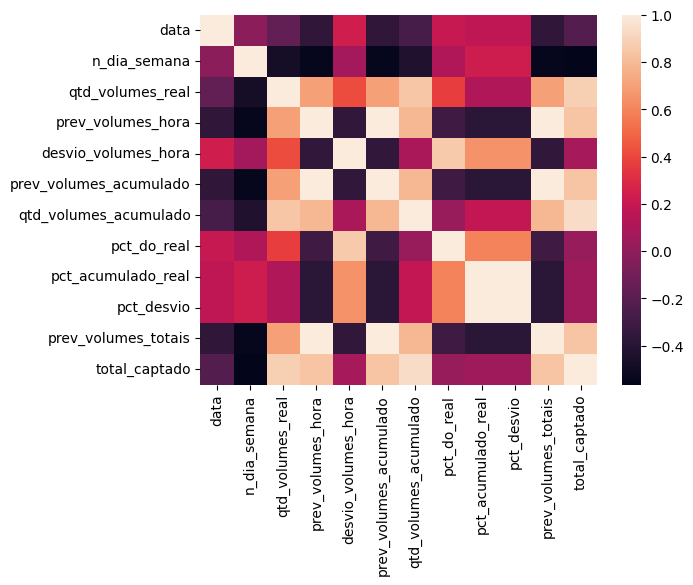

In [12]:
sns.heatmap(df.corr())

## Definido features e target

In [13]:
print(f"Total de linhas: {len(df)}")

Total de linhas: 272


In [14]:
print(f"Período: {df['data'].min().date()} a {df['data'].max().date()}")

Período: 2025-10-01 a 2026-07-01


In [15]:
df.columns

Index(['data', 'n_dia_semana', 'qtd_volumes_real', 'prev_volumes_hora',
       'desvio_volumes_hora', 'prev_volumes_acumulado',
       'qtd_volumes_acumulado', 'pct_do_real', 'pct_acumulado_real',
       'pct_desvio', 'prev_volumes_totais', 'total_captado'],
      dtype='object')

In [16]:
features = [
    'data',
    'n_dia_semana',          # dia da semana (0=seg, 6=dom)
    'qtd_volumes_real',      # quantidade de volumes real
    'prev_volumes_hora',     # esperado captar naquela hora
    'desvio_volumes_hora',   # desvios de volumes na hora
    'prev_volumes_acumulado',
    'qtd_volumes_acumulado',
    'pct_do_real',
    'pct_acumulado_real',
    'pct_desvio',
    'prev_volumes_totais',
]

In [17]:
target = 'total_captado'

In [18]:
features #x

['data',
 'n_dia_semana',
 'qtd_volumes_real',
 'prev_volumes_hora',
 'desvio_volumes_hora',
 'prev_volumes_acumulado',
 'qtd_volumes_acumulado',
 'pct_do_real',
 'pct_acumulado_real',
 'pct_desvio',
 'prev_volumes_totais']

In [19]:
target #Y

'total_captado'

## Dividir entre treino e teste

In [20]:
df[features].head()

,data,n_dia_semana,qtd_volumes_real,prev_volumes_hora,desvio_volumes_hora,prev_volumes_acumulado,qtd_volumes_acumulado,pct_do_real,pct_acumulado_real,pct_desvio,prev_volumes_totais
0,2025-10-01,2,375,470,-95,2973,2298,5.53,33.86,-9.94,6787
1,2025-10-02,3,322,472,-150,2984,2214,4.73,32.50,-11.30,6812
2,2025-10-03,4,314,418,-104,2643,1777,5.20,29.45,-14.35,6033
3,2025-10-04,5,176,99,77,626,1192,12.32,83.41,39.61,1429
4,2025-10-05,6,118,147,-29,928,842,5.57,39.75,-4.05,2118


In [21]:
round(len(df[features]) * 0.4)

109

In [22]:
df_treino = df.loc[:108]
df_teste = df.loc[109:]

In [23]:
df_treino.head()


,data,n_dia_semana,qtd_volumes_real,prev_volumes_hora,desvio_volumes_hora,prev_volumes_acumulado,qtd_volumes_acumulado,pct_do_real,pct_acumulado_real,pct_desvio,prev_volumes_totais,total_captado
0,2025-10-01,2,375,470,-95,2973,2298,5.53,33.86,-9.94,6787,5009
1,2025-10-02,3,322,472,-150,2984,2214,4.73,32.50,-11.30,6812,4655
2,2025-10-03,4,314,418,-104,2643,1777,5.20,29.45,-14.35,6033,3529
3,2025-10-04,5,176,99,77,626,1192,12.32,83.41,39.61,1429,2304
4,2025-10-05,6,118,147,-29,928,842,5.57,39.75,-4.05,2118,1735


In [24]:
df_teste.head()

,data,n_dia_semana,qtd_volumes_real,prev_volumes_hora,desvio_volumes_hora,prev_volumes_acumulado,qtd_volumes_acumulado,pct_do_real,pct_acumulado_real,pct_desvio,prev_volumes_totais,total_captado
109,2026-01-19,0,289,290,-1,1833,1836,6.91,43.89,0.09,4183,4234
110,2026-01-20,1,261,281,-20,1777,1735,6.43,42.78,-1.02,4056,4425
111,2026-01-21,2,278,266,12,1680,1763,7.25,45.97,2.17,3835,3997
112,2026-01-22,3,297,314,-17,1987,1932,6.55,42.59,-1.21,4536,4110
113,2026-01-23,4,223,294,-71,1860,1554,5.25,36.61,-7.19,4245,3260


In [25]:
X_train = df_treino[features].drop("data", axis=1)
y_train = df_treino[target]
X_test = df_teste[features].drop("data", axis=1)
y_test = df_teste[target]

## Modelo simples de regressão

In [26]:
clf = tree.DecisionTreeRegressor()

In [27]:
clf.fit(X_train, y_train)

DecisionTreeRegressor()

In [28]:
y_pred_train = clf.predict(X_train)

[Text(0.49915703275529866, 0.9615384615384616, 'x[1] <= 324.5\nsquared_error = 5650660.805\nsamples = 109\nvalue = 5026.679'),
 Text(0.2353082851637765, 0.8846153846153846, 'x[5] <= 1642.5\nsquared_error = 1469236.081\nsamples = 54\nvalue = 3006.741'),
 Text(0.3672326589595376, 0.9230769230769231, 'True  '),
 Text(0.13439306358381503, 0.8076923076923077, 'x[1] <= 151.5\nsquared_error = 472505.197\nsamples = 33\nvalue = 2244.212'),
 Text(0.06358381502890173, 0.7307692307692307, 'x[5] <= 679.0\nsquared_error = 177644.947\nsamples = 13\nvalue = 1548.231'),
 Text(0.030828516377649325, 0.6538461538461539, 'x[6] <= 4.925\nsquared_error = 71918.25\nsamples = 4\nvalue = 1027.5'),
 Text(0.015414258188824663, 0.5769230769230769, 'x[9] <= 1500.5\nsquared_error = 8100.0\nsamples = 2\nvalue = 767.0'),
 Text(0.007707129094412331, 0.5, 'squared_error = 0.0\nsamples = 1\nvalue = 677.0'),
 Text(0.023121387283236993, 0.5, 'squared_error = 0.0\nsamples = 1\nvalue = 857.0'),
 Text(0.046242774566473986, 0.

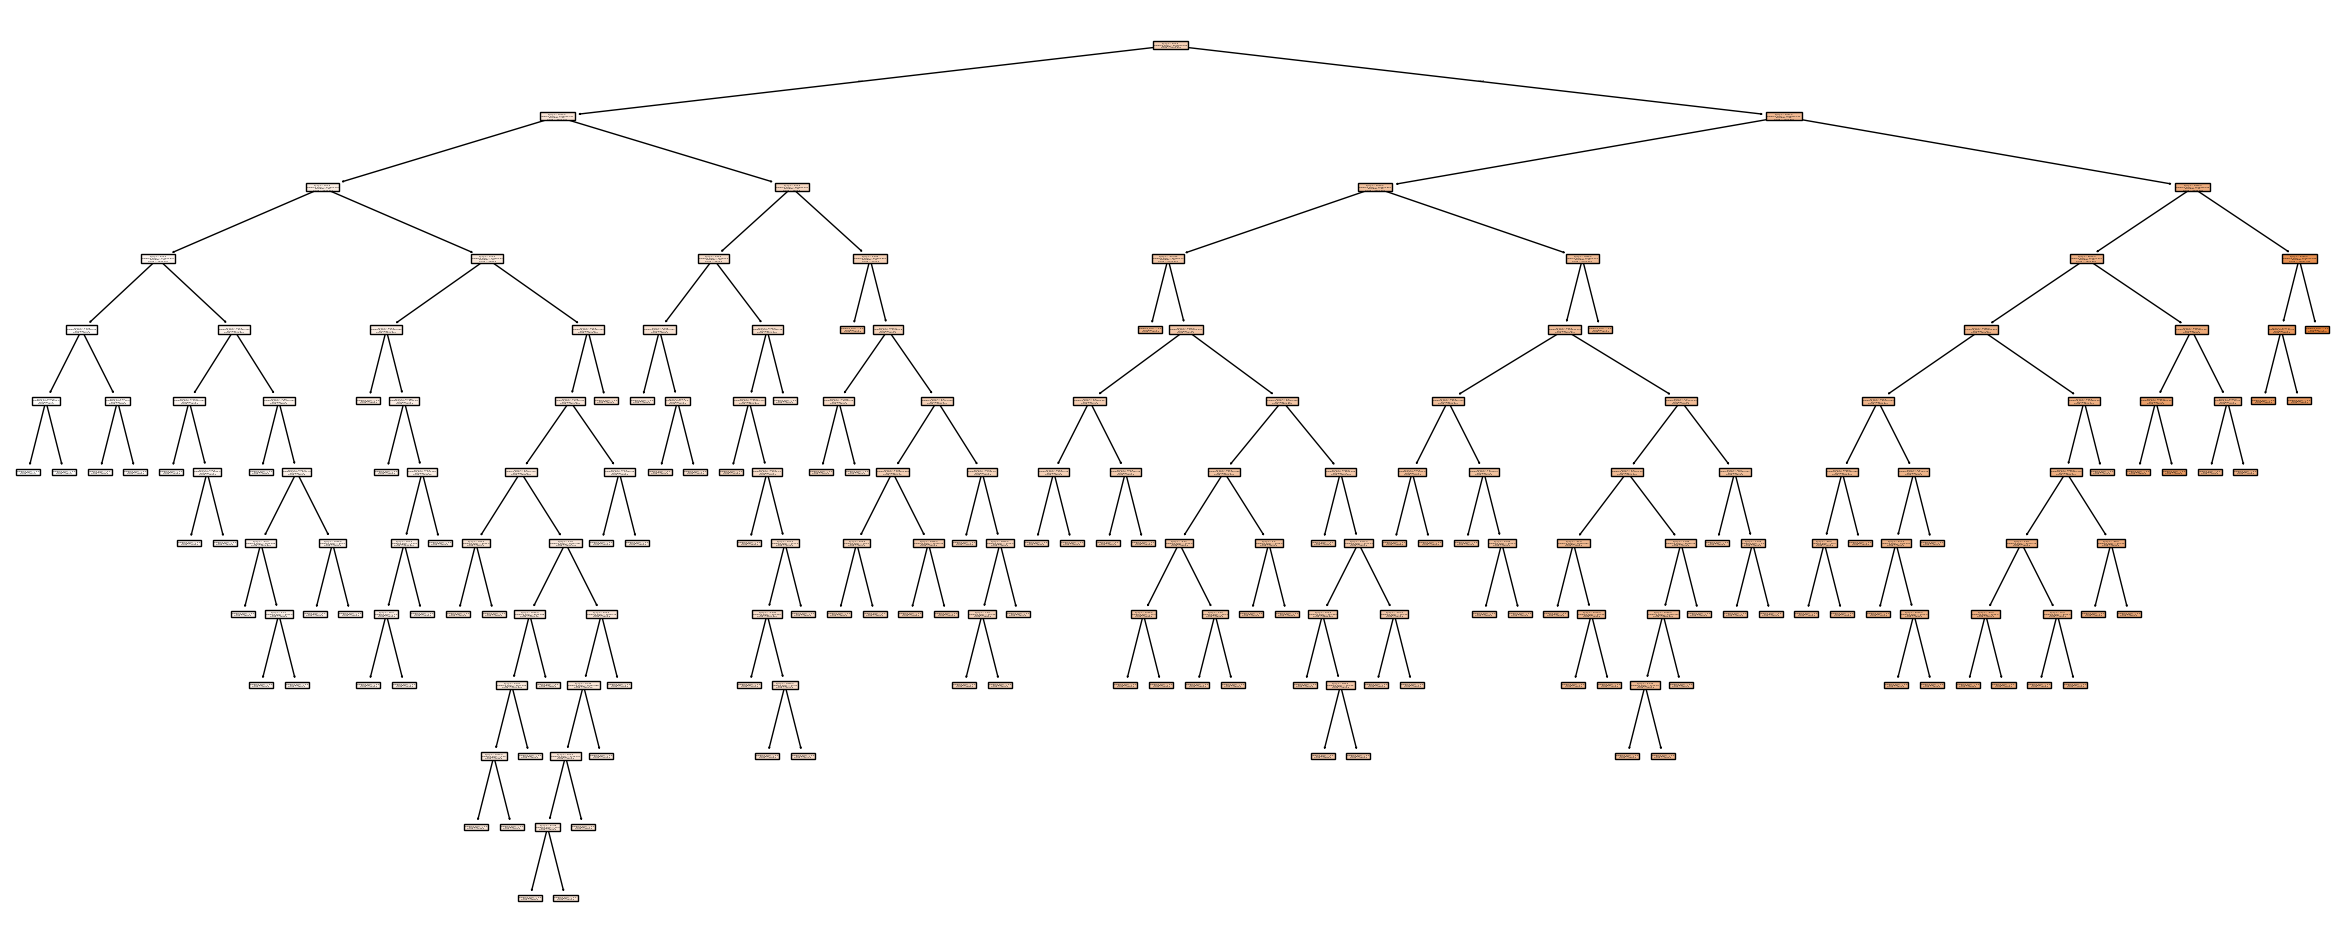

In [29]:
plt.figure(figsize=(30,12))
tree.plot_tree(clf, filled=True )

In [30]:

mae = mean_absolute_error(y_train, y_pred_train)
rmse = mean_squared_error(y_train, y_pred_train) # squared=False tira a raiz quadrada
mape = mean_absolute_percentage_error(y_train, y_pred_train)
r2 = r2_score(y_train, y_pred_train)

print(f"MAE (Erro Médio): {mae:.2f} volumes")
print(f"RMSE (Erro com peso em picos): {rmse:.2f} volumes")
print(f"MAPE (Erro Percentual): {mape * 100:.2f}%")
print(f"R²: {r2:.4f}")

MAE (Erro Médio): 0.00 volumes
RMSE (Erro com peso em picos): 0.00 volumes
MAPE (Erro Percentual): 0.00%
R²: 1.0000


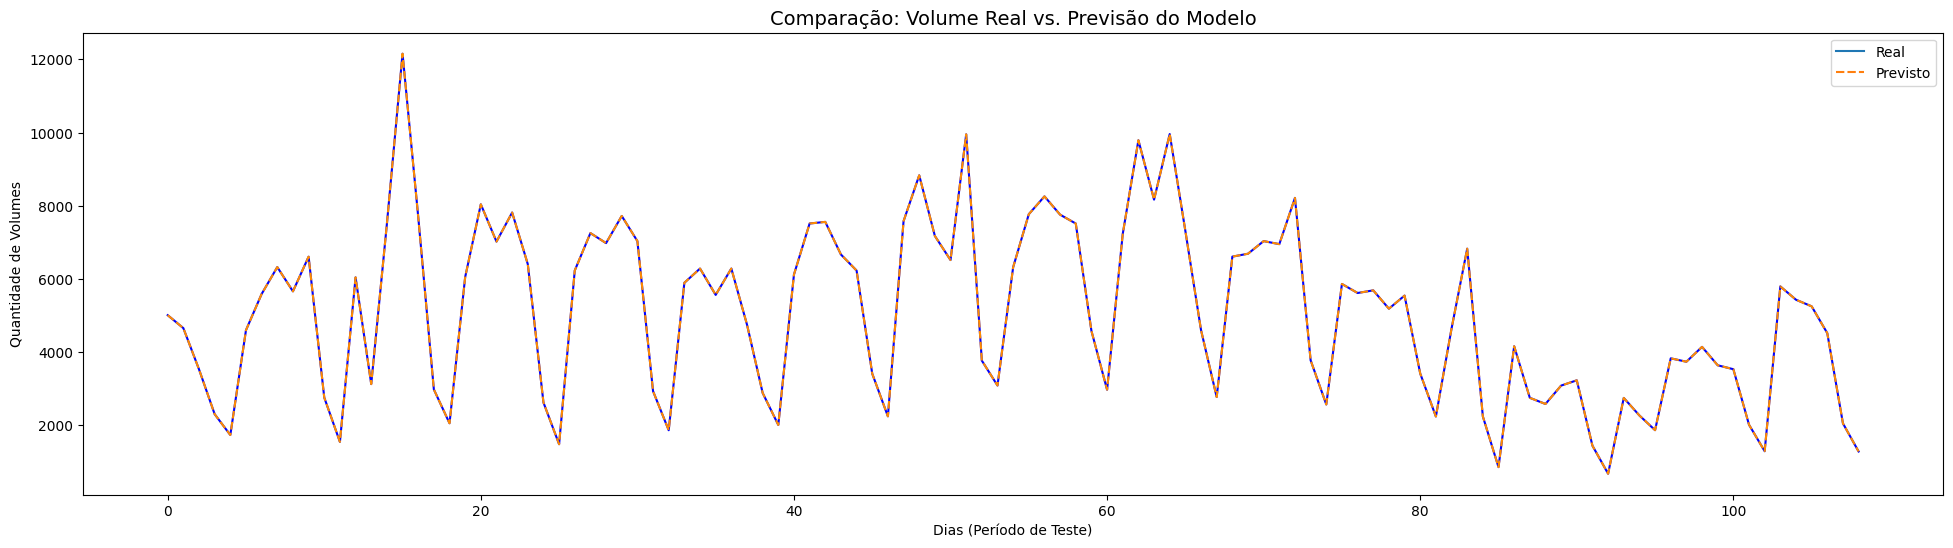

In [31]:
df_comparacao = pd.DataFrame({
    'Real': y_train.values,
    'Previsto': y_pred_train
})

fig, ax = plt.subplots(figsize=(24, 6))

# Plota as duas linhas
sns.lineplot(data=df_comparacao, ax=ax)

ax.set_title("Comparação: Volume Real vs. Previsão do Modelo", fontsize=14)
ax.set_xlabel("Dias (Período de Teste)")
ax.set_ylabel("Quantidade de Volumes")

# Ajusta as cores para ficar claro (Real em azul, Previsto em laranja tracejado)
ax.lines[0].set_color('blue')
ax.lines[1].set_color('darkorange')
ax.lines[1].set_linestyle('--')

## Ajustando o Overfiting

In [32]:
clf1 = tree.DecisionTreeRegressor(max_depth=5, min_samples_leaf=5, criterion='absolute_error')

In [33]:
clf1.fit(X_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=5,
                      min_samples_leaf=5)

[Text(0.47794117647058826, 0.9166666666666666, 'x[1] <= 297.0\nabsolute_error = 2041.459\nsamples = 109\nvalue = 5251.0'),
 Text(0.23529411764705882, 0.75, 'x[5] <= 1253.0\nabsolute_error = 772.196\nsamples = 46\nvalue = 2749.5'),
 Text(0.35661764705882354, 0.8333333333333333, 'True  '),
 Text(0.11764705882352941, 0.5833333333333334, 'x[5] <= 943.5\nabsolute_error = 430.095\nsamples = 21\nvalue = 2009.0'),
 Text(0.058823529411764705, 0.4166666666666667, 'x[1] <= 114.0\nabsolute_error = 308.8\nsamples = 10\nvalue = 1463.0'),
 Text(0.029411764705882353, 0.25, 'absolute_error = 240.2\nsamples = 5\nvalue = 1284.0'),
 Text(0.08823529411764706, 0.25, 'absolute_error = 169.2\nsamples = 5\nvalue = 1735.0'),
 Text(0.17647058823529413, 0.4166666666666667, 'x[1] <= 162.0\nabsolute_error = 204.0\nsamples = 11\nvalue = 2245.0'),
 Text(0.14705882352941177, 0.25, 'absolute_error = 105.333\nsamples = 6\nvalue = 2054.0'),
 Text(0.20588235294117646, 0.25, 'absolute_error = 156.4\nsamples = 5\nvalue = 25

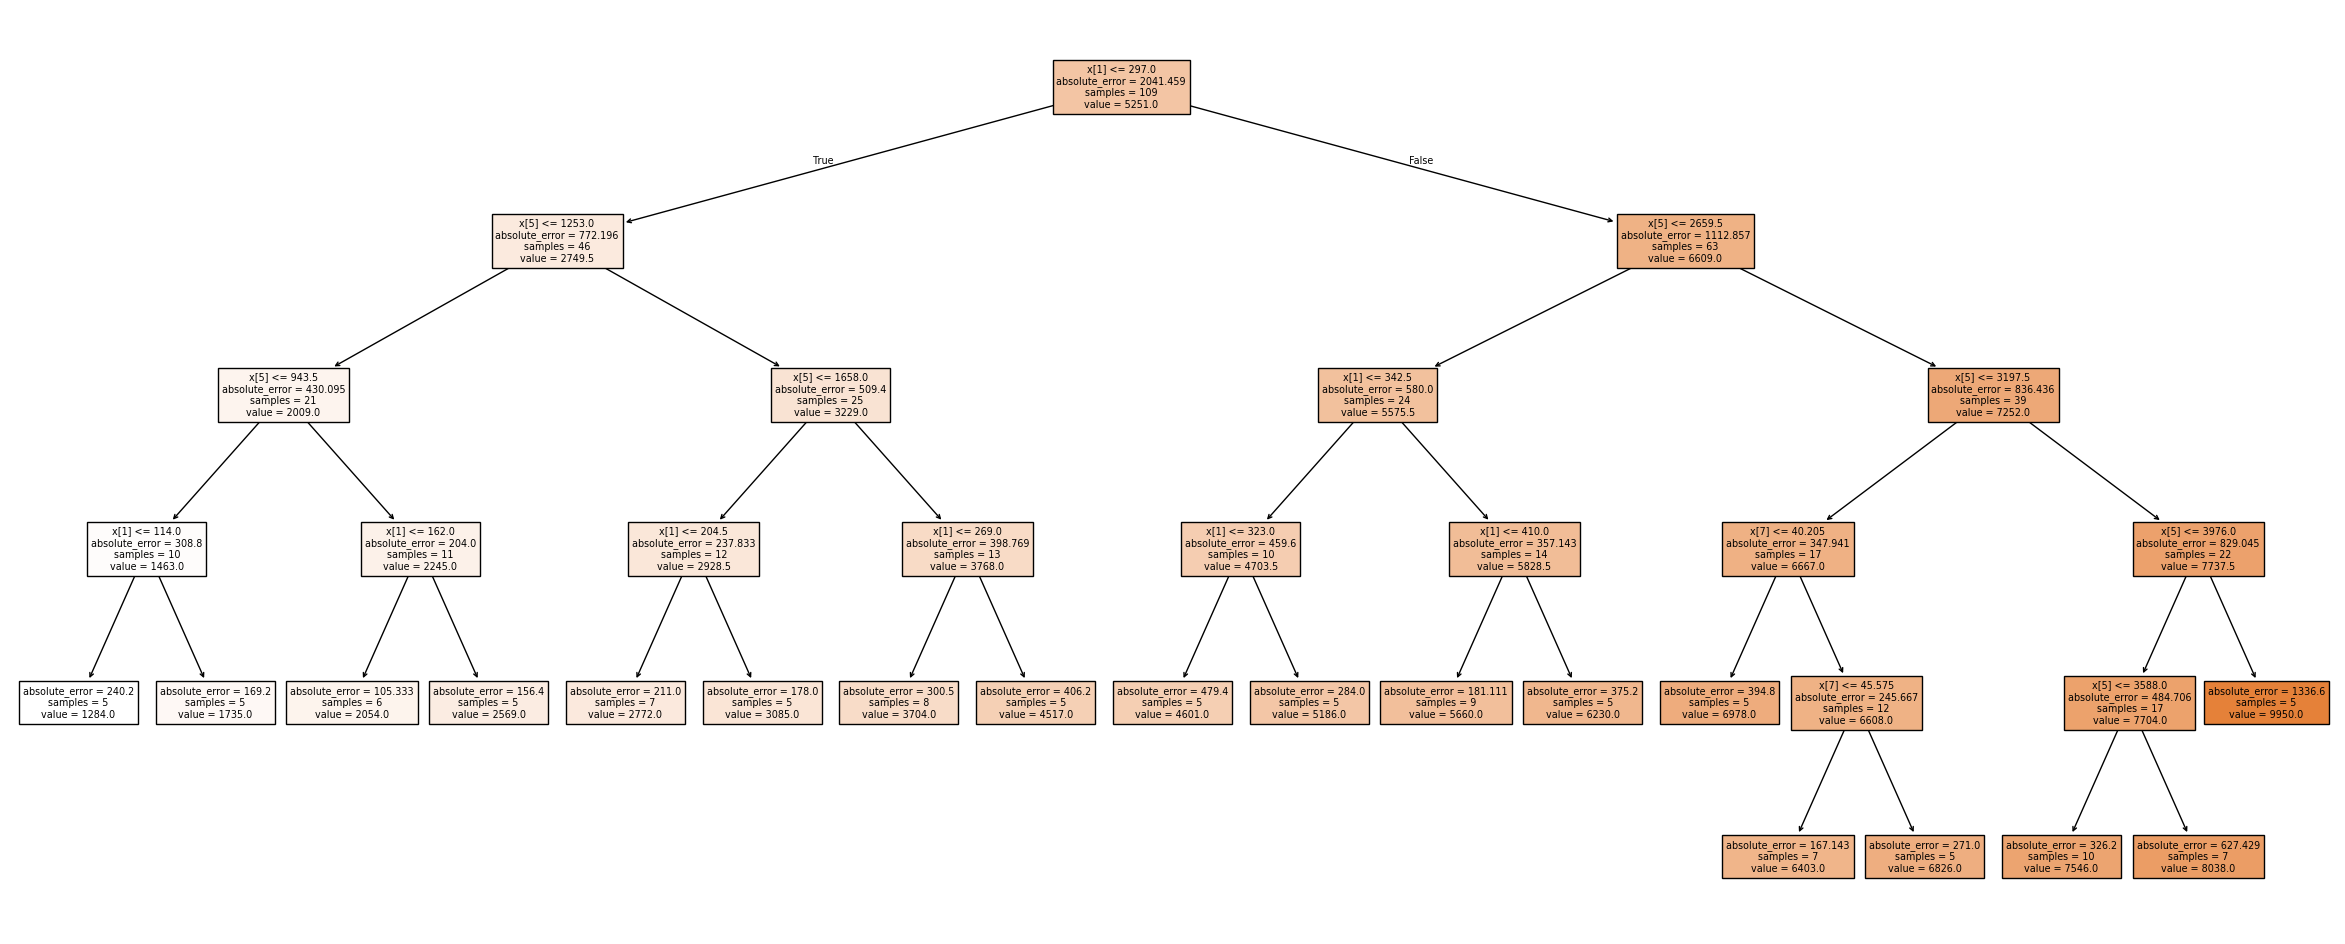

In [34]:
plt.figure(figsize=(30,12))
tree.plot_tree(clf1, filled=True )

In [35]:
clf1_pred_train = clf1.predict(X_train)

### Métricas de erro

In [36]:

mae = mean_absolute_error(y_train, clf1_pred_train)
rmse = mean_squared_error(y_train, clf1_pred_train) # squared=False tira a raiz quadrada
mape = mean_absolute_percentage_error(y_train, clf1_pred_train)
r2 = r2_score(y_train, clf1_pred_train)

print(f"MAE (Erro Médio): {mae:.2f} volumes")
print(f"RMSE (Erro com peso em picos): {rmse:.2f} volumes")
print(f"MAPE (Erro Percentual): {mape * 100:.2f}%")
print(f"R²: {r2:.4f}")

MAE (Erro Médio): 334.15 volumes
RMSE (Erro com peso em picos): 330250.84 volumes
MAPE (Erro Percentual): 7.90%
R²: 0.9416


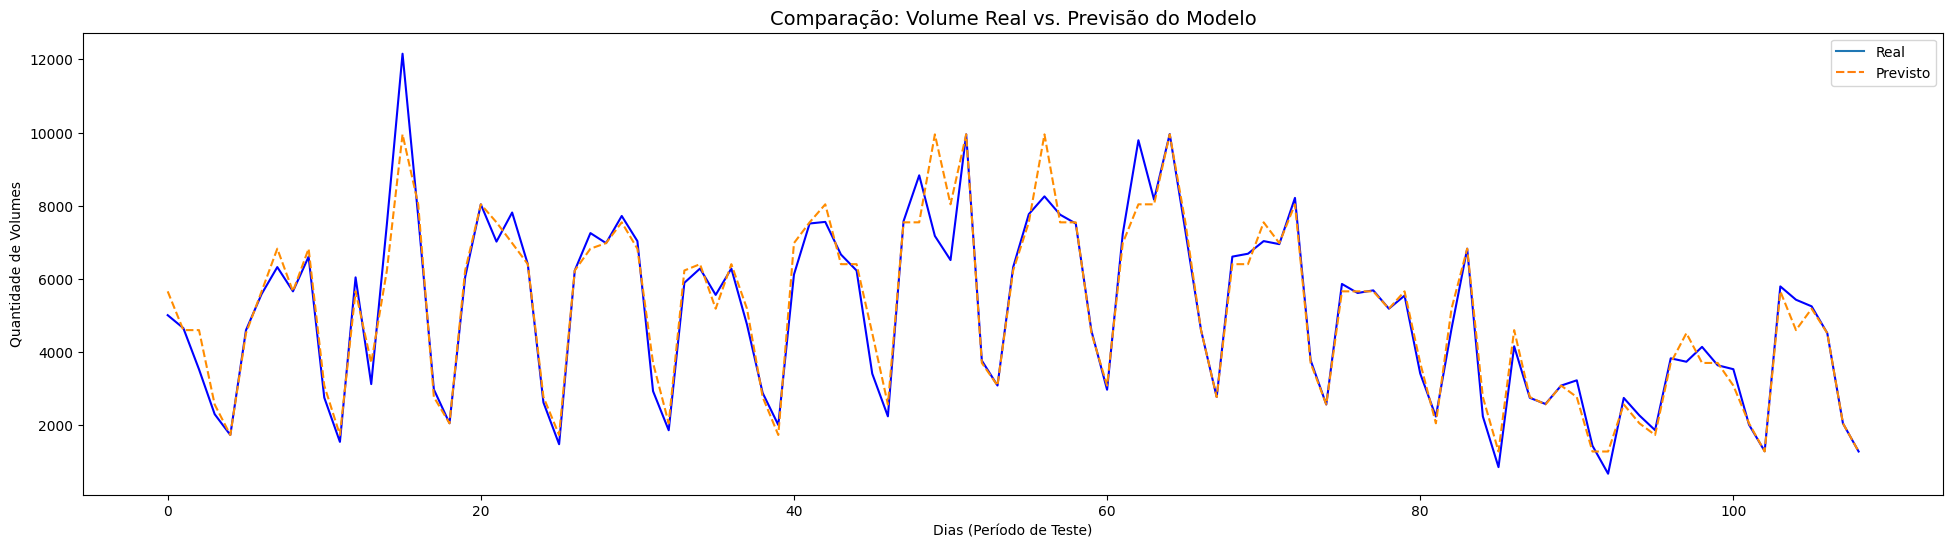

In [37]:
df_comparacao = pd.DataFrame({
    'Real': y_train.values,
    'Previsto': clf1_pred_train
})

fig, ax = plt.subplots(figsize=(24, 6))

# Plota as duas linhas
sns.lineplot(data=df_comparacao, ax=ax)

ax.set_title("Comparação: Volume Real vs. Previsão do Modelo", fontsize=14)
ax.set_xlabel("Dias (Período de Teste)")
ax.set_ylabel("Quantidade de Volumes")

# Ajusta as cores para ficar claro (Real em azul, Previsto em laranja tracejado)
ax.lines[0].set_color('blue')
ax.lines[1].set_color('darkorange')
ax.lines[1].set_linestyle('--')

## Testando o clf1 com dados de teste

In [38]:
clf1_pred_test = clf1.predict(X_test)

### Métricas de erro

In [39]:

mae = mean_absolute_error(y_test, clf1_pred_test)
rmse = mean_squared_error(y_test, clf1_pred_test) # squared=False tira a raiz quadrada
mape = mean_absolute_percentage_error(y_test, clf1_pred_test)
r2 = r2_score(y_test, clf1_pred_test)

print(f"MAE (Erro Médio): {mae:.2f} volumes")
print(f"RMSE (Erro com peso em picos): {rmse:.2f} volumes")
print(f"MAPE (Erro Percentual): {mape * 100:.2f}%")
print(f"R²: {r2:.4f}")

MAE (Erro Médio): 454.03 volumes
RMSE (Erro com peso em picos): 479794.95 volumes
MAPE (Erro Percentual): 13.83%
R²: 0.8025


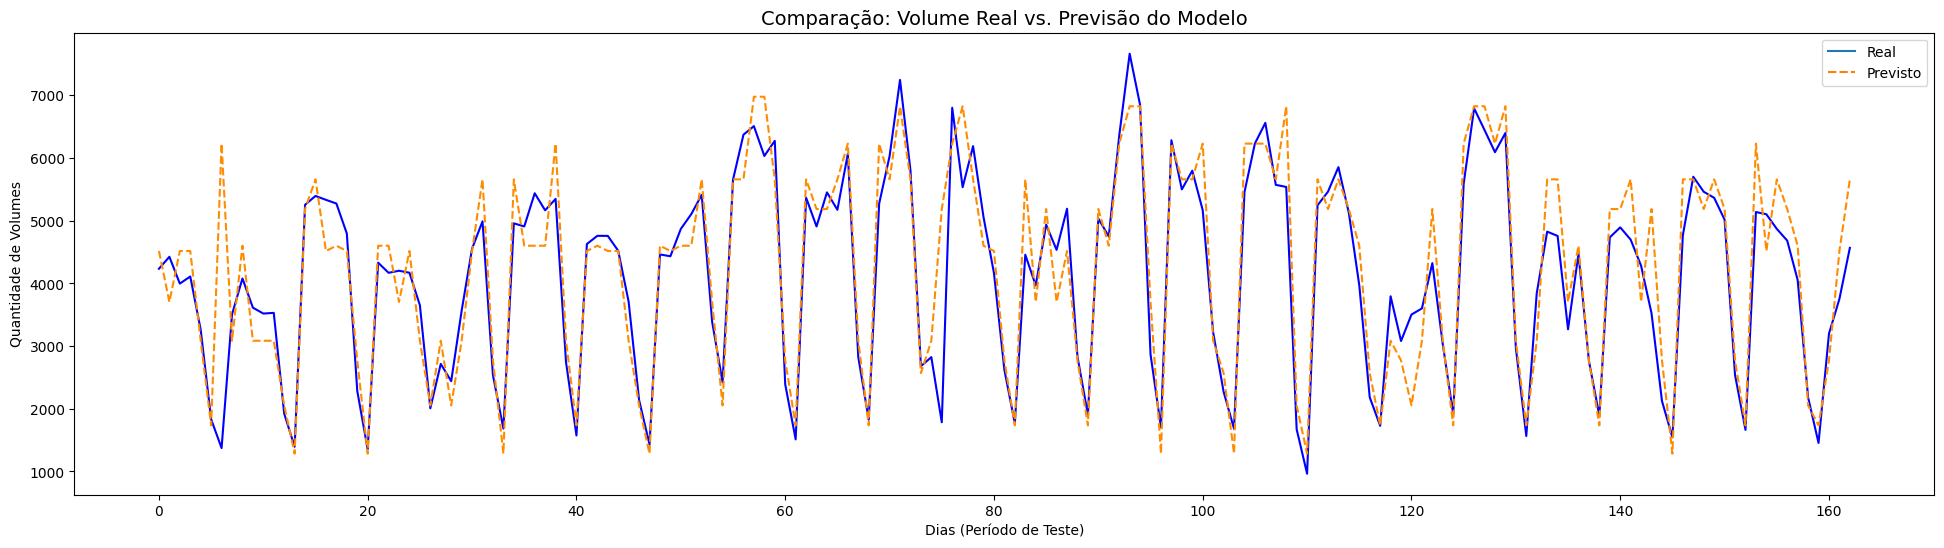

In [40]:
df_comparacao = pd.DataFrame({
    'Real': y_test.values,
    'Previsto': clf1_pred_test
})

fig, ax = plt.subplots(figsize=(24, 6))

# Plota as duas linhas
sns.lineplot(data=df_comparacao, ax=ax)

ax.set_title("Comparação: Volume Real vs. Previsão do Modelo", fontsize=14)
ax.set_xlabel("Dias (Período de Teste)")
ax.set_ylabel("Quantidade de Volumes")

# Ajusta as cores para ficar claro (Real em azul, Previsto em laranja tracejado)
ax.lines[0].set_color('blue')
ax.lines[1].set_color('darkorange')
ax.lines[1].set_linestyle('--')

In [41]:
X_train

,n_dia_semana,qtd_volumes_real,prev_volumes_hora,desvio_volumes_hora,prev_volumes_acumulado,qtd_volumes_acumulado,pct_do_real,pct_acumulado_real,pct_desvio,prev_volumes_totais
0,2,375,470,-95,2973,2298,5.53,33.86,-9.94,6787
1,3,322,472,-150,2984,2214,4.73,32.50,-11.30,6812
2,4,314,418,-104,2643,1777,5.20,29.45,-14.35,6033
3,5,176,99,77,626,1192,12.32,83.41,39.61,1429
4,6,118,147,-29,928,842,5.57,39.75,-4.05,2118
...,...,...,...,...,...,...,...,...,...,...
104,2,312,354,-42,2239,2462,6.10,48.17,4.37,5111
105,3,334,361,-27,2282,2107,6.41,40.46,-3.34,5208
106,4,291,391,-100,2472,1996,5.16,35.37,-8.43,5643
107,5,150,171,-21,1081,1140,6.08,46.23,2.43,2466


In [42]:
hoje = {
  'n_dia_semana': 2,
  'qtd_volumes_real': 329,
  'prev_volumes_hora': 250,
  'desvio_volumes_hora': 79,
  'prev_volumes_acumulado': 1571,
  'qtd_volumes_acumulado': 2485,
  'pct_do_real': 9.17,
  'pct_acumulado_real': 69.26,
  'pct_desvio': 25.5,
  'prev_volumes_totais': 3588
}

In [43]:
pd.DataFrame(hoje, index=[0])

,n_dia_semana,qtd_volumes_real,prev_volumes_hora,desvio_volumes_hora,prev_volumes_acumulado,qtd_volumes_acumulado,pct_do_real,pct_acumulado_real,pct_desvio,prev_volumes_totais
0,2,329,250,79,1571,2485,9.17,69.26,25.5,3588


In [44]:
ontem = {
  'n_dia_semana': 1,
  'qtd_volumes_real': 333,
  'prev_volumes_hora': 250,
  'desvio_volumes_hora': 83,
  'prev_volumes_acumulado': 1570,
  'qtd_volumes_acumulado': 2011,
  'pct_do_real': 9.28,
  'pct_acumulado_real': 56.06,
  'pct_desvio': 12.3,
  'prev_volumes_totais': 3587
}

In [45]:
clf1.predict(pd.DataFrame(hoje, index=[0]))

array([5186.])

In [46]:
clf1.predict(pd.DataFrame(ontem, index=[0]))

array([5186.])

In [47]:
clf1.feature_importances_

array([0.        , 0.6802474 , 0.        , 0.        , 0.        ,
       0.31214367, 0.        , 0.00760894, 0.        , 0.        ])

In [48]:
X_test.columns

Index(['n_dia_semana', 'qtd_volumes_real', 'prev_volumes_hora',
       'desvio_volumes_hora', 'prev_volumes_acumulado',
       'qtd_volumes_acumulado', 'pct_do_real', 'pct_acumulado_real',
       'pct_desvio', 'prev_volumes_totais'],
      dtype='object')

In [49]:
features_importantes = pd.DataFrame({
    'Feature': X_train.columns,
    'Importância': clf1.feature_importances_
})

In [50]:
features_importantes

,Feature,Importância
0,n_dia_semana,0.000000
1,qtd_volumes_real,0.680247
2,prev_volumes_hora,0.000000
3,desvio_volumes_hora,0.000000
4,prev_volumes_acumulado,0.000000
5,qtd_volumes_acumulado,0.312144
6,pct_do_real,0.000000
7,pct_acumulado_real,0.007609
8,pct_desvio,0.000000
9,prev_volumes_totais,0.000000


##Nova árvore usando o critério voltados para séries temporais

In [51]:
clf2 = clf1.set_params(criterion='squared_error')

[Text(0.47794117647058826, 0.9166666666666666, 'x[1] <= 297.0\nsquared_error = 2041.459\nsamples = 109\nvalue = 5251.0'),
 Text(0.23529411764705882, 0.75, 'x[5] <= 1253.0\nsquared_error = 772.196\nsamples = 46\nvalue = 2749.5'),
 Text(0.35661764705882354, 0.8333333333333333, 'True  '),
 Text(0.11764705882352941, 0.5833333333333334, 'x[5] <= 943.5\nsquared_error = 430.095\nsamples = 21\nvalue = 2009.0'),
 Text(0.058823529411764705, 0.4166666666666667, 'x[1] <= 114.0\nsquared_error = 308.8\nsamples = 10\nvalue = 1463.0'),
 Text(0.029411764705882353, 0.25, 'squared_error = 240.2\nsamples = 5\nvalue = 1284.0'),
 Text(0.08823529411764706, 0.25, 'squared_error = 169.2\nsamples = 5\nvalue = 1735.0'),
 Text(0.17647058823529413, 0.4166666666666667, 'x[1] <= 162.0\nsquared_error = 204.0\nsamples = 11\nvalue = 2245.0'),
 Text(0.14705882352941177, 0.25, 'squared_error = 105.333\nsamples = 6\nvalue = 2054.0'),
 Text(0.20588235294117646, 0.25, 'squared_error = 156.4\nsamples = 5\nvalue = 2569.0'),
 

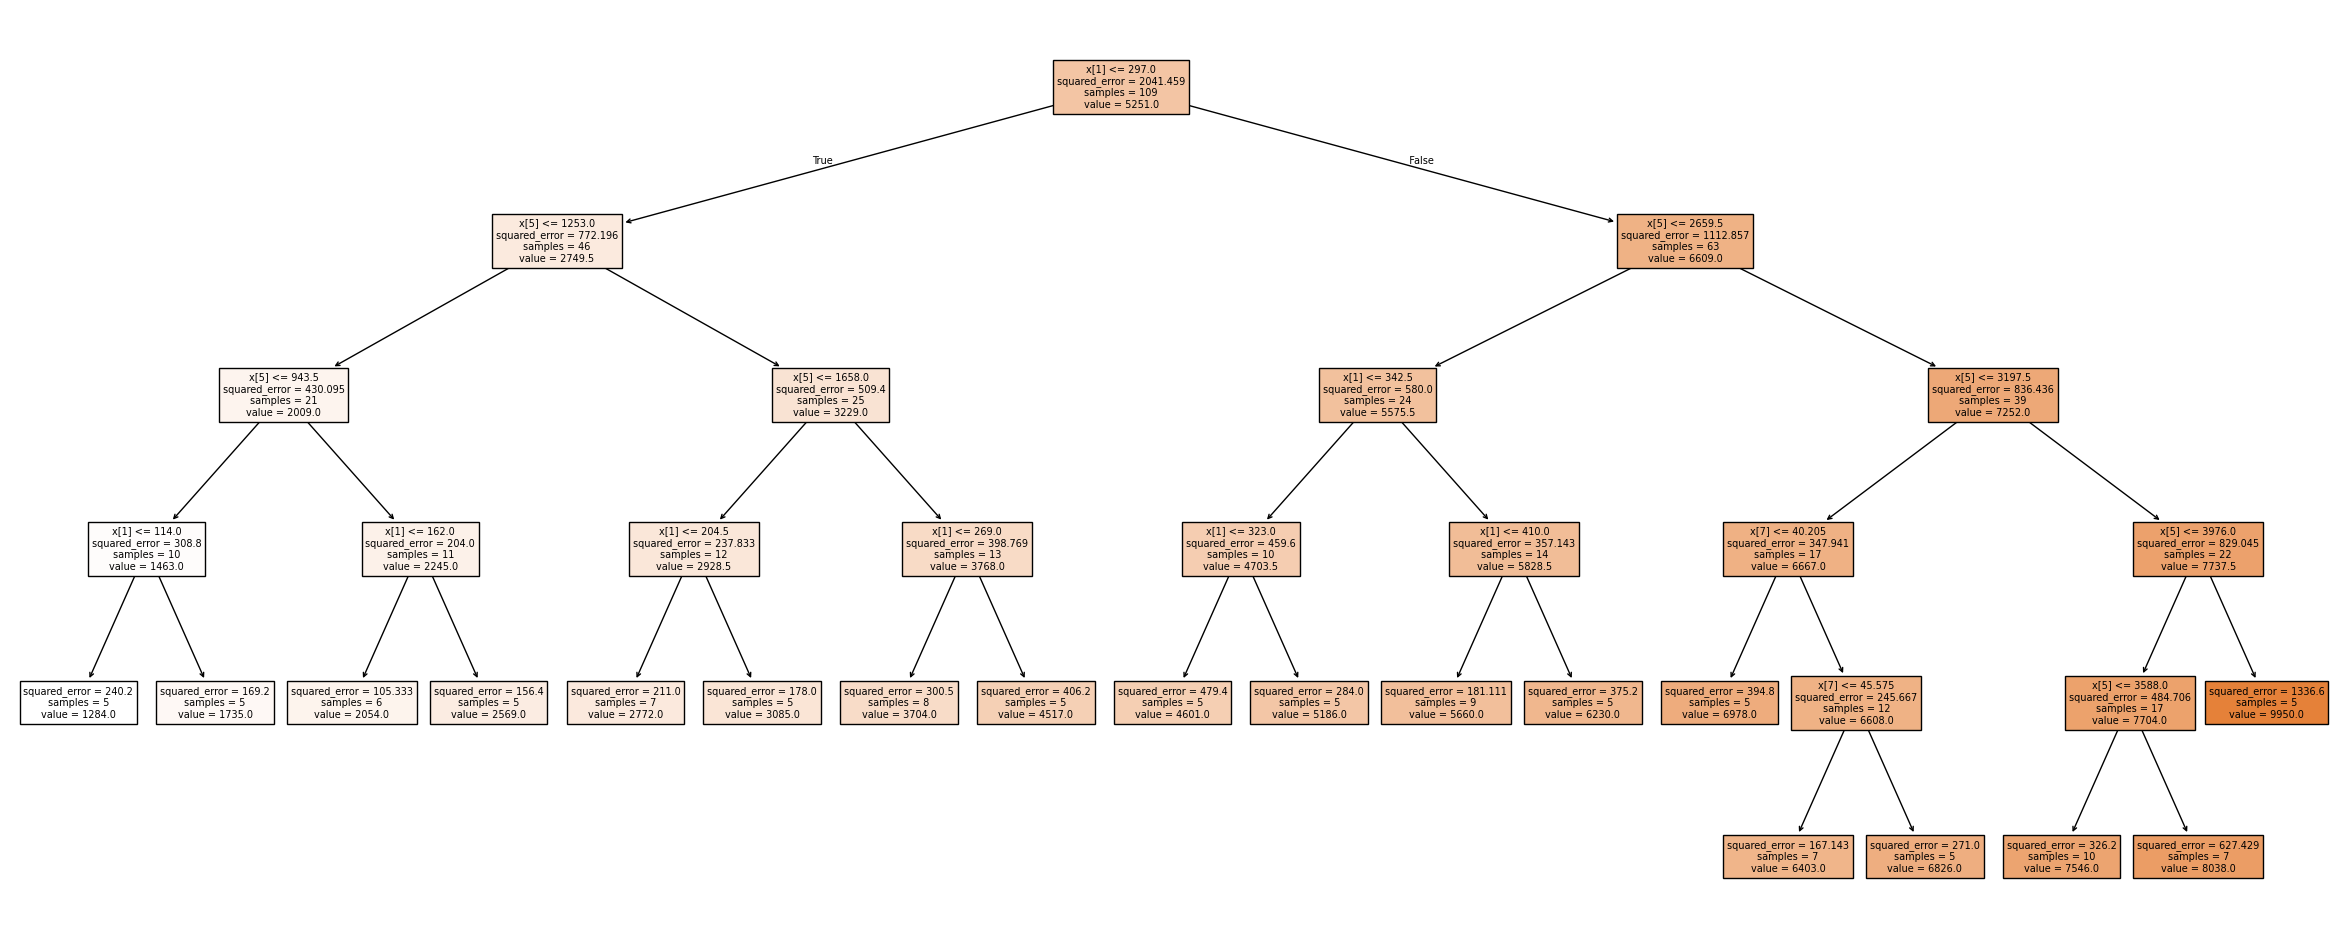

In [52]:
plt.figure(figsize=(30,12))
tree.plot_tree(clf2, filled=True )

## Métricas de erro para treino


In [53]:
clf2_pred = clf1.predict(X_train)

In [54]:

mae = mean_absolute_error(y_train, clf2_pred)
rmse = mean_squared_error(y_train, clf2_pred) # squared=False tira a raiz quadrada
mape = mean_absolute_percentage_error(y_train, clf2_pred)
r2 = r2_score(y_train, clf2_pred)

print(f"MAE (Erro Médio): {mae:.2f} volumes")
print(f"RMSE (Erro com peso em picos): {rmse:.2f} volumes")
print(f"MAPE (Erro Percentual): {mape * 100:.2f}%")
print(f"R²: {r2:.4f}")

MAE (Erro Médio): 334.15 volumes
RMSE (Erro com peso em picos): 330250.84 volumes
MAPE (Erro Percentual): 7.90%
R²: 0.9416


## Comparação

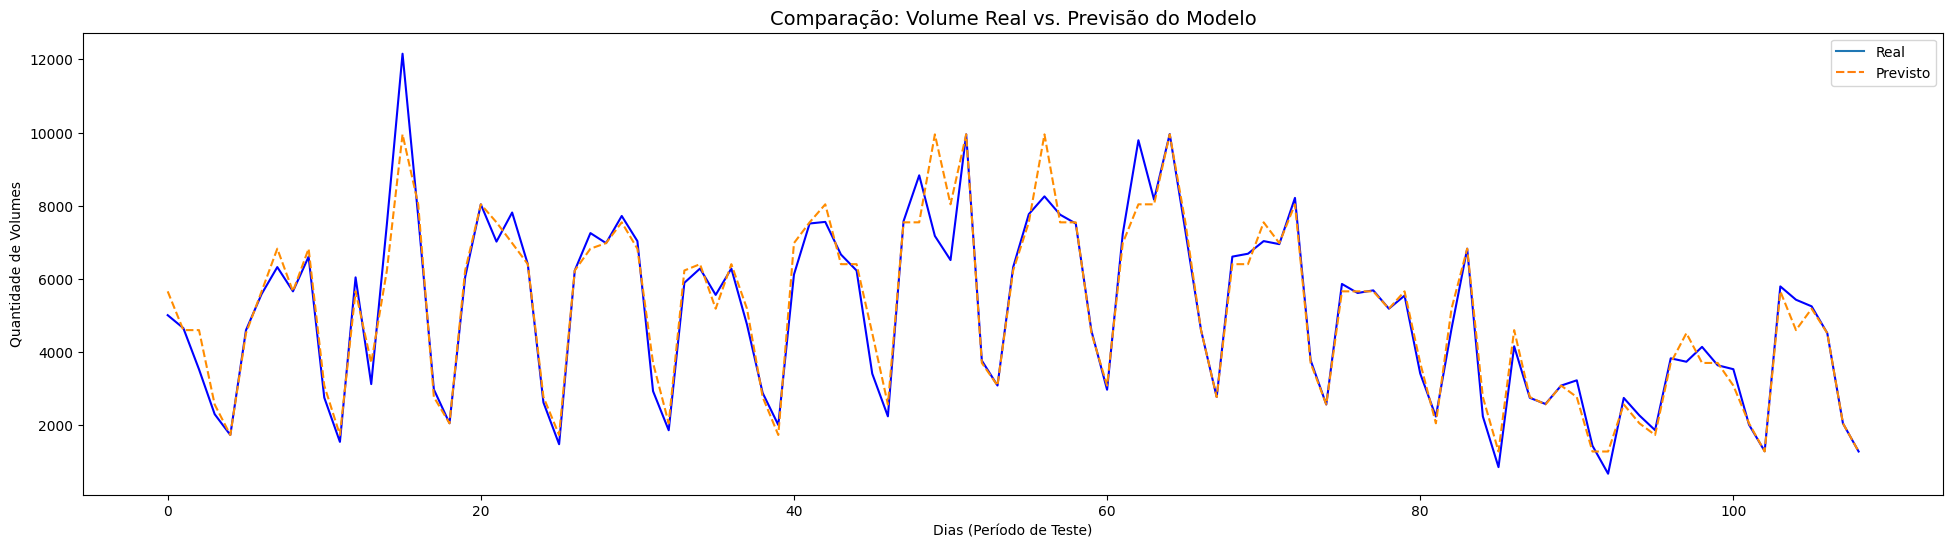

In [55]:
df_comparacao = pd.DataFrame({
    'Real': y_train.values,
    'Previsto': clf2_pred
})

fig, ax = plt.subplots(figsize=(24, 6))

# Plota as duas linhas
sns.lineplot(data=df_comparacao, ax=ax)

ax.set_title("Comparação: Volume Real vs. Previsão do Modelo", fontsize=14)
ax.set_xlabel("Dias (Período de Teste)")
ax.set_ylabel("Quantidade de Volumes")

# Ajusta as cores para ficar claro (Real em azul, Previsto em laranja tracejado)
ax.lines[0].set_color('blue')
ax.lines[1].set_color('darkorange')
ax.lines[1].set_linestyle('--')

In [56]:
features_importantes = pd.DataFrame({
    'Feature': X_train.columns,
    'Importância': clf2.feature_importances_
})

In [57]:
features_importantes

,Feature,Importância
0,n_dia_semana,0.000000
1,qtd_volumes_real,0.680247
2,prev_volumes_hora,0.000000
3,desvio_volumes_hora,0.000000
4,prev_volumes_acumulado,0.000000
5,qtd_volumes_acumulado,0.312144
6,pct_do_real,0.000000
7,pct_acumulado_real,0.007609
8,pct_desvio,0.000000
9,prev_volumes_totais,0.000000


## Métricas de errro para dados de teste

In [58]:
clf2_test_predict = clf2.predict(X_test)

In [59]:
mae = mean_absolute_error(y_test, clf2_test_predict)
rmse = mean_squared_error(y_test, clf2_test_predict) # squared=False tira a raiz quadrada
mape = mean_absolute_percentage_error(y_test, clf2_test_predict)
r2 = r2_score(y_test, clf2_test_predict)

print(f"MAE (Erro Médio): {mae:.2f} volumes")
print(f"RMSE (Erro com peso em picos): {rmse:.2f} volumes")
print(f"MAPE (Erro Percentual): {mape * 100:.2f}%")
print(f"R²: {r2:.4f}")

MAE (Erro Médio): 454.03 volumes
RMSE (Erro com peso em picos): 479794.95 volumes
MAPE (Erro Percentual): 13.83%
R²: 0.8025


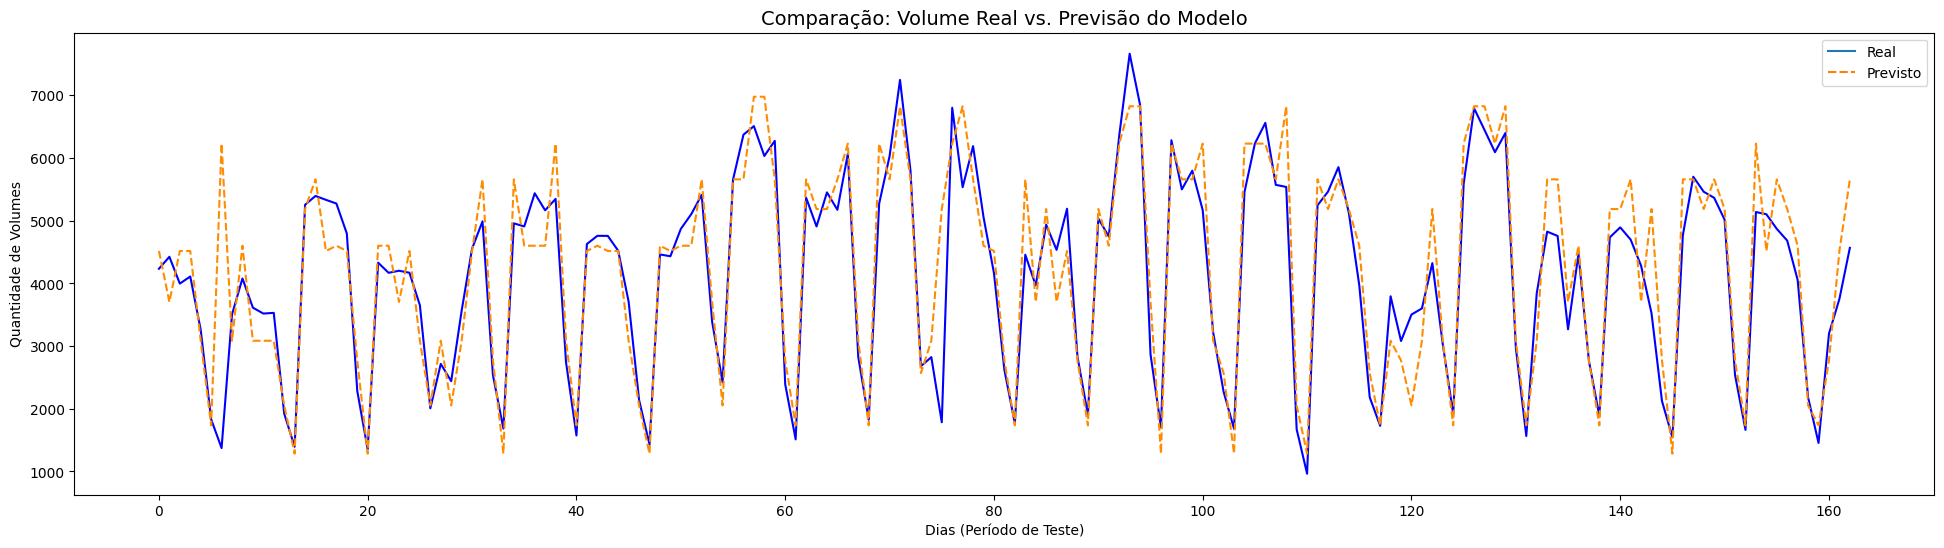

In [60]:
df_comparacao = pd.DataFrame({
    'Real': y_test.values,
    'Previsto': clf2_test_predict
})

fig, ax = plt.subplots(figsize=(24, 6))

# Plota as duas linhas
sns.lineplot(data=df_comparacao, ax=ax)

ax.set_title("Comparação: Volume Real vs. Previsão do Modelo", fontsize=14)
ax.set_xlabel("Dias (Período de Teste)")
ax.set_ylabel("Quantidade de Volumes")

# Ajusta as cores para ficar claro (Real em azul, Previsto em laranja tracejado)
ax.lines[0].set_color('blue')
ax.lines[1].set_color('darkorange')
ax.lines[1].set_linestyle('--')

In [61]:
clf2.predict(pd.DataFrame(ontem, index=[0]))

array([5186.])

In [62]:
clf2.predict(pd.DataFrame(hoje, index=[0]))

array([5186.])